# Turán RL v3 — CEnv + minimal PPO


In [11]:
%matplotlib inline
import sys
sys.path.insert(0, '.')
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from turan_env_c import CEnv, CHECKER_C3, CHECKER_C4, CHECKER_K4
from policy import MLPActorCritic
from ppo3 import train, load_checkpoint, CFG
print(f'torch: {torch.__version__}')
print(f'cuda:  {torch.cuda.is_available()}  {torch.cuda.get_device_name(0) if torch.cuda.is_available() else ""}')

torch: 2.10.0+cu130
cuda:  True  NVIDIA GeForce RTX 5090


## 1. Sanity check — CEnv

In [12]:
env = CEnv(n=10, num_envs=1, checker_id=CHECKER_C4)
env.reset()
print(f'obs shape:   {env.obs.shape}  <- should be (1, 100)')
print(f'num_actions: {env.num_actions}  <- should be 45')

def act(env, u, v):
    return int(np.where((env._edge_u == u) & (env._edge_v == v))[0])

for u, v in [(0,1),(1,2),(2,3)]:
    _, rew, done = env.step(np.array([act(env,u,v)], dtype=np.int32))
    print(f'  add ({u},{v}): r={rew[0]:+.2f}  done={done[0]}')
_, rew, done = env.step(np.array([act(env,0,3)], dtype=np.int32))
print(f'  add (0,3): r={rew[0]:+.2f}  done={done[0]}')
assert done[0] and rew[0] == 3.0, f'C4 broken rew={rew[0]} done={done[0]}'
print('C4: OK')
env.close()

obs shape:   (1, 100)  <- should be (1, 100)
num_actions: 45  <- should be 45
  add (0,1): r=-0.01  done=False
  add (1,2): r=-0.01  done=False
  add (2,3): r=-0.01  done=False
  add (0,3): r=+3.00  done=True
C4: OK


/tmp/ipykernel_7692/3574166914.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(np.where((env._edge_u == u) & (env._edge_v == v))[0])


In [13]:
bench = CEnv(n=20, num_envs=4096, checker_id=CHECKER_C4)
bench.benchmark(steps=500)
bench.close()

500 steps x 4096 envs in 0.07s
  30,822,322 steps/sec
  30.82M steps/sec


## 2. Train

In [14]:
env = CEnv(n=20, num_envs=4096, checker_id=CHECKER_C4)
env.reset()
for _ in range(1000):
    actions = np.random.randint(0, env.num_actions, env.num_envs, dtype=np.int32)
    _, reward, done = env.step(actions)
    if done.any():
        print(f'terminal rewards: {reward[done]}')
        break

terminal rewards: [3.]


In [28]:
CFG['n']             = 20
CFG['num_envs']      = 4096
CFG['checker_id']    = CHECKER_C4
CFG['n_steps']       = 64
CFG['batch_size']    = 2048
CFG['lr']            = 1e-5
CFG['ent_coef']      = 0.01
CFG['total_steps']   = 30_000_000
CFG['device']        = 'cuda' if torch.cuda.is_available() else 'cpu'
CFG['log_interval']  = 10
CFG['save_interval'] = 100
CFG['checkpoint_dir']= './checkpoints'

#policy, history = train(CFG)

In [29]:

policy, history = train(CFG, resume='./checkpoints/final.pt')

loaded ./checkpoints/final.pt  iter=76  steps=19,922,944  best=81.88

PPO  n=20  envs=4096  checker=1  device=cuda
transitions/update: 262,144   total iters: 114
params: 385,983

200 steps x 4096 envs in 0.02s
  45,058,997 steps/sec
  45.06M steps/sec
iter    80 | steps 20.97M | fps 101,269 | ret 48.28 | term 36.61 | best 228.69 | pg -0.0332 | vf 47.714 | ent 2.444 | clip 0.289 | t 10s
iter    90 | steps 23.59M | fps 106,742 | ret 38.46 | term 42.86 | best 228.69 | pg -0.0266 | vf 27.772 | ent 2.429 | clip 0.237 | t 35s
iter   100 | steps 26.21M | fps 122,164 | ret 39.06 | term 45.85 | best 228.69 | pg -0.0199 | vf 11.092 | ent 2.378 | clip 0.228 | t 59s
iter   110 | steps 28.84M | fps 104,088 | ret 30.92 | term 37.70 | best 228.69 | pg -0.0213 | vf 13.179 | ent 2.384 | clip 0.206 | t 83s

done. best return: 228.69


## 3. Training curves

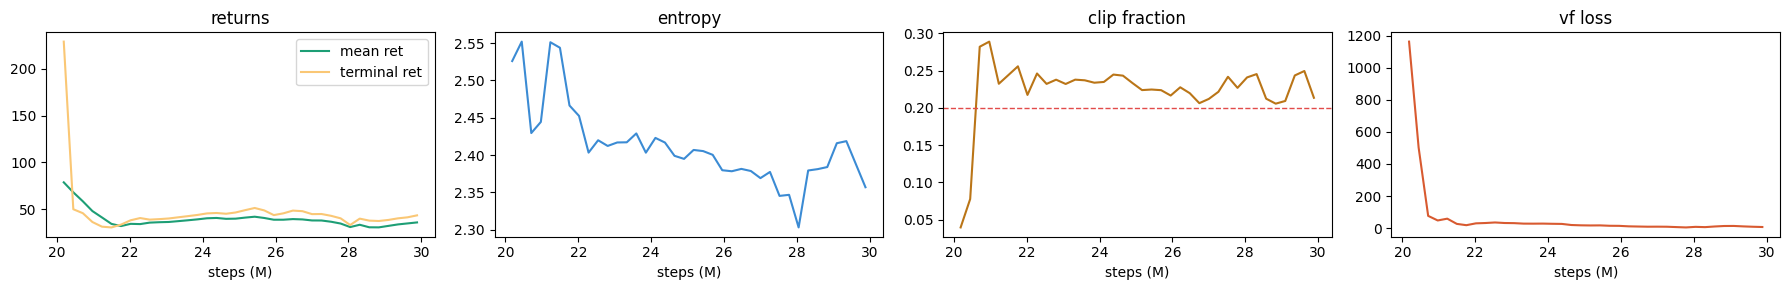

best terminal return: 228.69


In [30]:
steps      = [h['global_step'] / 1e6   for h in history]
rets       = [h['mean_ret']            for h in history]
term_rets  = [h['mean_term_ret']       for h in history]
ents       = [h['ent']                 for h in history]
clips      = [h['clip']                for h in history]

fig, axes = plt.subplots(1, 4, figsize=(18, 3))
axes[0].plot(steps, rets,      color='#1D9E75', lw=1.5, label='mean ret')
axes[0].plot(steps, term_rets, color='#FAC775', lw=1.5, label='terminal ret')
axes[0].set_title('returns'); axes[0].set_xlabel('steps (M)'); axes[0].legend()
axes[1].plot(steps, ents,  color='#3B8BD4', lw=1.5)
axes[1].set_title('entropy'); axes[1].set_xlabel('steps (M)')
axes[2].plot(steps, clips, color='#BA7517', lw=1.5)
axes[2].axhline(0.2, color='#E24B4A', lw=1, linestyle='--')
axes[2].set_title('clip fraction'); axes[2].set_xlabel('steps (M)')
axes[3].plot(steps, [h['vf'] for h in history], color='#D85A30', lw=1.5)
axes[3].set_title('vf loss'); axes[3].set_xlabel('steps (M)')
plt.tight_layout()
plt.show()
print(f'best terminal return: {max(term_rets):.2f}')

## 4. Load checkpoint

In [31]:
policy, optimizer, cfg, iteration, global_step, best_ret = \
    load_checkpoint('./checkpoints/final.pt')
policy.eval()
print(f'best terminal return: {best_ret:.2f}')

loaded ./checkpoints/final.pt  iter=114  steps=29,884,416  best=228.69
best terminal return: 228.69


## 5. Inference

In [32]:
def run_episodes(policy, cfg, n_episodes=1, deterministic=True):
    n      = cfg['n']
    device = cfg['device']
    env    = CEnv(n=n, num_envs=n_episodes, checker_id=cfg['checker_id'])
    env.reset()
    done_all = np.zeros(n_episodes, dtype=bool)
    last_obs = np.zeros((n_episodes, n*n), dtype=np.float32)
    max_steps = n*(n-1)//2 + 10
    step = 0
    while not done_all.all() and step < max_steps:
        obs_t = torch.tensor(env.obs.astype(np.float32), device=device)
        with torch.no_grad():
            logits, _ = policy(obs_t)
            added = torch.from_numpy(
                env.obs[:, env._edge_u * n + env._edge_v].astype(bool)
            ).to(device)
            logits[added] = -1e9
            action = logits.argmax(dim=-1) if deterministic else \
                     torch.distributions.Categorical(logits=logits).sample()
        _, _, done_arr = env.step(action.cpu().numpy().astype(np.int32))
        newly_done = done_arr & ~done_all
        for e in np.where(newly_done)[0]:
            last_obs[e] = obs_t[e].cpu().numpy()
        done_all |= done_arr
        step += 1
    for e in np.where(~done_all)[0]:
        last_obs[e] = obs_t[e].cpu().numpy()
    env.close()
    return [last_obs[e].reshape(n, n) for e in range(n_episodes)]

def draw_adj(adj, ax=None, title=''):
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    G       = nx.from_numpy_array(adj)
    pos     = nx.spring_layout(G, seed=0)
    edges   = int(adj.sum()) // 2
    degrees = sorted(adj.sum(axis=1).astype(int).tolist(), reverse=True)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color='#1D9E75',
            node_size=500, font_color='white', edge_color='#444')
    ax.set_title(f'{title}edges={edges}')
    if show:
        plt.show()
        print(f'edges={edges}  degrees={degrees}')
    return edges, degrees

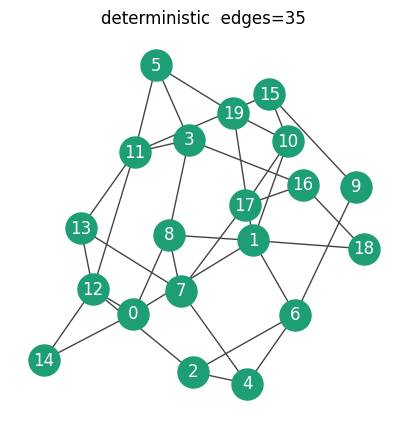

edges=35  degrees=[6, 5, 5, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2]


(35, [6, 5, 5, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2])

In [33]:
adjs = run_episodes(policy, cfg, n_episodes=1, deterministic=True)
draw_adj(adjs[0], title='deterministic  ')

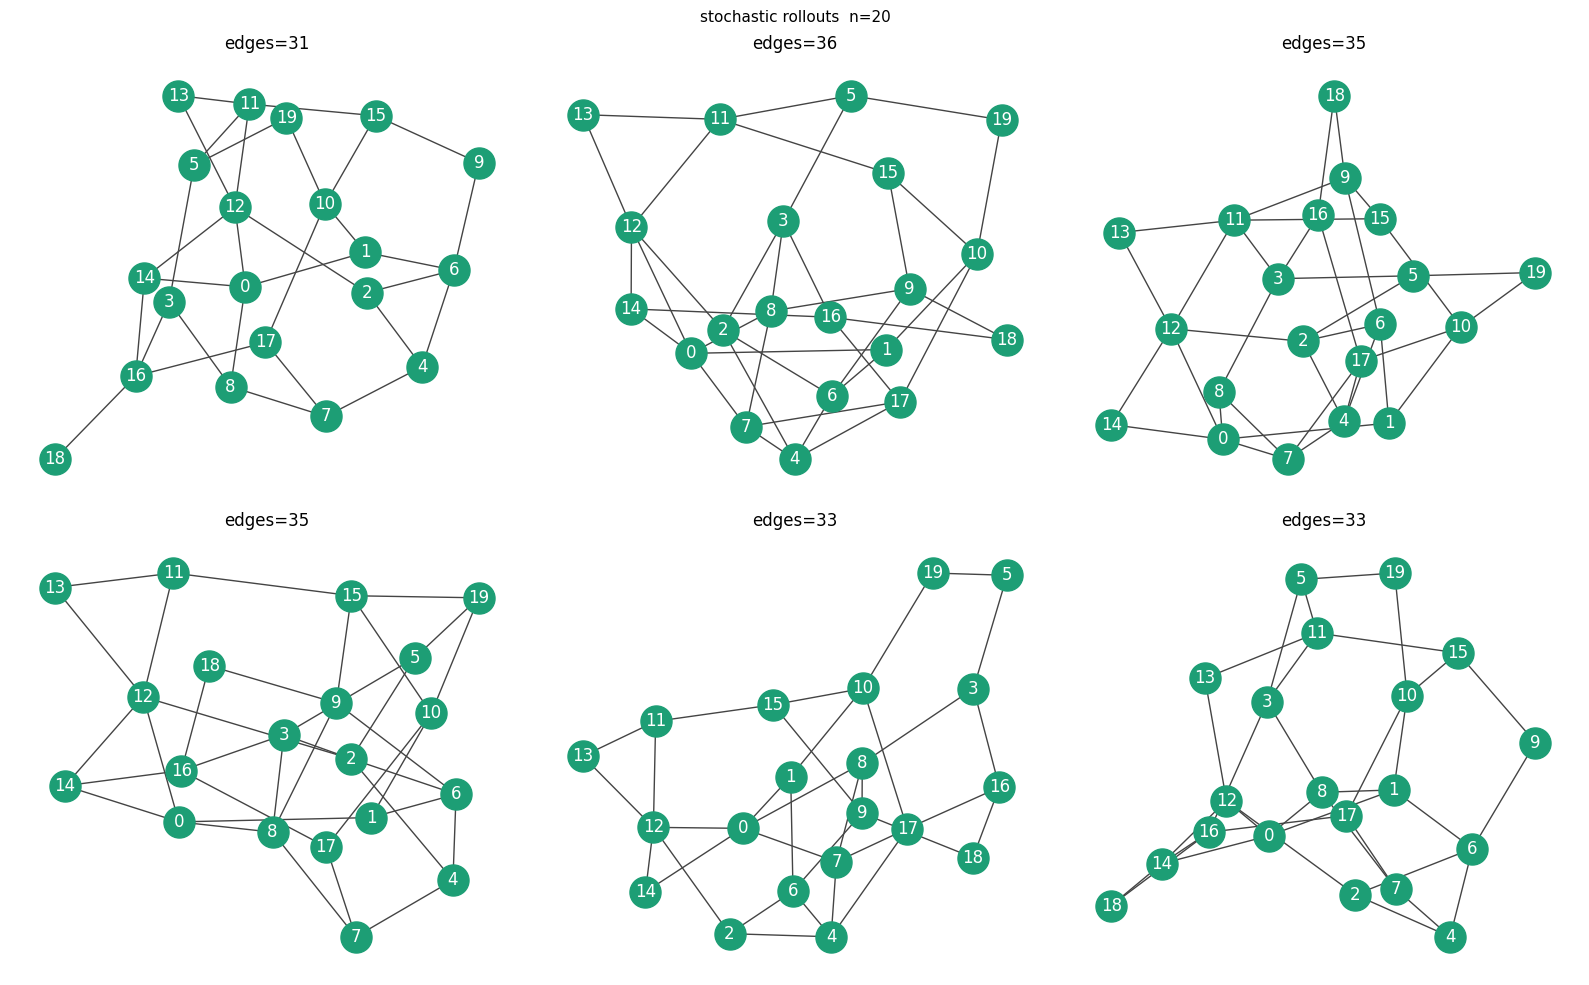

In [34]:
adjs = run_episodes(policy, cfg, n_episodes=6, deterministic=False)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, adj in zip(axes.flatten(), adjs):
    draw_adj(adj, ax=ax)
plt.suptitle(f'stochastic rollouts  n={cfg["n"]}', fontsize=11)
plt.tight_layout()
plt.show()

mean=35.8  max=40  min=29  std=1.9


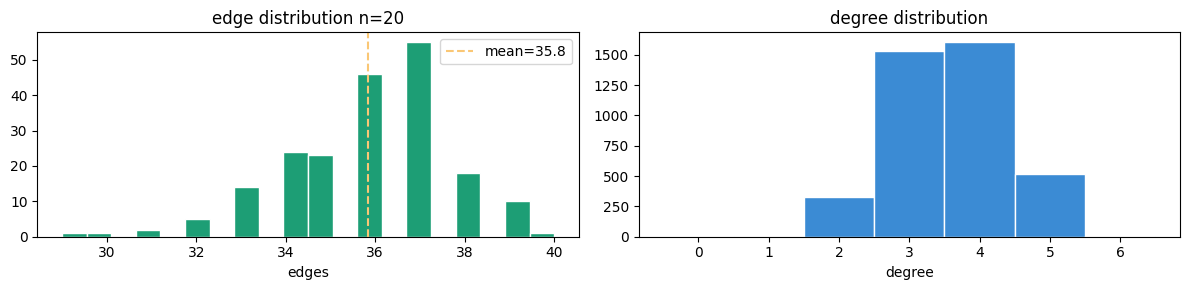

In [22]:
n_trials = 200
adjs     = run_episodes(policy, cfg, n_episodes=n_trials, deterministic=False)
results  = np.array([int(adj.sum())//2 for adj in adjs])
print(f"mean={results.mean():.1f}  max={results.max()}  min={results.min()}  std={results.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(results, bins=20, color='#1D9E75', edgecolor='white')
axes[0].axvline(results.mean(), color='#FAC775', lw=1.5, linestyle='--', label=f'mean={results.mean():.1f}')
axes[0].set_xlabel('edges'); axes[0].set_title(f'edge distribution n={cfg["n"]}'); axes[0].legend()
all_deg = [d for adj in adjs for d in adj.sum(axis=1).astype(int).tolist()]
axes[1].hist(all_deg, bins=range(0, max(all_deg)+2), color='#3B8BD4', edgecolor='white', align='left')
axes[1].set_xlabel('degree'); axes[1].set_title('degree distribution')
plt.tight_layout()
plt.show()